# 02 - Minimal Public REST Ingestion

Checkpoint 1: real-ID discovery, tiny sample retrieval, preliminary normalization, and validation. This is not a full-night alert census and should not be used for population-level science claims.

In [1]:
from pathlib import Path
import os
import pandas as pd

if Path.cwd().name == "notebooks":
    os.chdir(Path.cwd().parent)

from fink_lsst.storage import read_json
from fink_lsst.summaries import missingness_summary, numeric_ranges, group_counts
from fink_lsst.plotting import sky_scatter, numeric_histogram, categorical_bar_counts

paths = {
    "id_candidates": Path("outputs/id_discovery/id_candidates.json"),
    "id_manifest": Path("outputs/id_discovery/id_discovery_manifest.json"),
    "endpoint_attempts": Path("outputs/minimal_ingestion/sample_endpoint_attempts.json"),
    "normalization_report": Path("outputs/minimal_ingestion/normalization_report.json"),
    "validation_report": Path("outputs/minimal_ingestion/validation_report.json"),
    "validation_summary": Path("outputs/minimal_ingestion/validation_summary.md"),
}
pd.DataFrame([{"artifact": key, "exists": value.exists(), "path": str(value)} for key, value in paths.items()])

,artifact,exists,path
0,id_candidates,True,outputs/id_discovery/id_candidates.json
1,id_manifest,True,outputs/id_discovery/id_discovery_manifest.json
2,endpoint_attempts,True,outputs/minimal_ingestion/sample_endpoint_atte...
3,normalization_report,True,outputs/minimal_ingestion/normalization_report...
4,validation_report,True,outputs/minimal_ingestion/validation_report.json
5,validation_summary,True,outputs/minimal_ingestion/validation_summary.md


## Candidate IDs

In [2]:
candidates = read_json(paths["id_candidates"]) if paths["id_candidates"].exists() else {}
display(pd.DataFrame(candidates.get("summary", [])))
candidates.get("selected", {})

,count,example_values,id_type,sources
0,2,"[170560739209117700, 170560743138132015]",diaObjectId,[/Users/darim_shamsi/Documents/Fink Analysis/d...
1,3,"[170560743369867270, 170560743233028170, 17056...",diaSourceId,[/Users/darim_shamsi/Documents/Fink Analysis/d...
2,0,[],other_object_ids,[]
3,0,[],other_source_ids,[]


{'object': {'confidence': 'high',
  'field': 'r:diaObjectId',
  'id_type': 'diaObjectId',
  'origin': 'fink_lsst_tags_id_lookup_sample.json',
  'payload_path': '$[0].r:diaObjectId',
  'reason': 'Found field `r:diaObjectId` in payload',
  'source_path': '/Users/darim_shamsi/Documents/Fink Analysis/data/fixtures/samples/fink_lsst_tags_id_lookup_sample.json',
  'value': '170560739209117700'},
 'source': {'confidence': 'high',
  'field': 'r:diaSourceId',
  'id_type': 'diaSourceId',
  'origin': 'fink_lsst_tags_id_lookup_sample.json',
  'payload_path': '$[2].r:diaSourceId',
  'reason': 'Found field `r:diaSourceId` in payload',
  'source_path': '/Users/darim_shamsi/Documents/Fink Analysis/data/fixtures/samples/fink_lsst_tags_id_lookup_sample.json',
  'value': '170560743138132015'}}

## Endpoint Retrieval Status

In [3]:
attempts = pd.DataFrame(read_json(paths["endpoint_attempts"])) if paths["endpoint_attempts"].exists() else pd.DataFrame()
display(attempts[[column for column in ["name", "ok", "method", "url", "status_code", "content_type", "output_file", "skip_reason", "error"] if column in attempts.columns]])

,name,ok,method,url,status_code,content_type,output_file,error
0,objects,True,POST,https://api.lsst.fink-portal.org/api/v1/objects,200,application/json,/Users/darim_shamsi/Documents/Fink Analysis/da...,None
1,sources,True,POST,https://api.lsst.fink-portal.org/api/v1/sources,200,application/json,/Users/darim_shamsi/Documents/Fink Analysis/da...,None
2,fp,True,POST,https://api.lsst.fink-portal.org/api/v1/fp,200,application/json,/Users/darim_shamsi/Documents/Fink Analysis/da...,None


## Normalized Tables

In [4]:
table_dir = Path("data/processed/minimal_samples")
tables = {}
for path in sorted(table_dir.glob("*.parquet")):
    tables[path.stem] = pd.read_parquet(path)

pd.DataFrame([{"table": name, "rows": len(df), "columns": len(df.columns)} for name, df in tables.items()])

,table,rows,columns
0,forced_photometry,1,20
1,objects,1,12
2,sources,2,21
3,statistics,81,24
4,tags,9,5


In [5]:
for name, df in tables.items():
    print(f"\n{name}: {df.shape}")
    display(df.head())
    display(missingness_summary(df).head(10))
    display(numeric_ranges(df).head(10))


forced_photometry: (1, 20)


,r:band,r:dec,r:diaForcedSourceId,r:diaObjectId,r:midpointMjdTai,r:psfFlux,r:psfFluxErr,r:ra,r:scienceFlux,r:scienceFluxErr,internal_table_type,internal_object_id,internal_source_id,ra,dec,time_mjd,band,flux,flux_err,_unmapped_fields
0,i,-9.816786,170560743369867266,170560739209117700,61211.433583,26574.172,2900.527,340.693877,94697.47,2918.7747,forced_photometry,170560739209117700,170560743369867266,340.693877,-9.816786,61211.433583,i,26574.172,2900.527,"[""r:scienceFlux"", ""r:scienceFluxErr""]"


,column,missing,missing_fraction
19,_unmapped_fields,0,0.0
16,band,0,0.0
14,dec,0,0.0
17,flux,0,0.0
18,flux_err,0,0.0
11,internal_object_id,0,0.0
12,internal_source_id,0,0.0
10,internal_table_type,0,0.0
0,r:band,0,0.0
1,r:dec,0,0.0


,column,non_null,min,max
0,r:dec,1,-9.816786e+00,-9.816786e+00
1,r:diaForcedSourceId,1,1.705607e+17,1.705607e+17
2,r:diaObjectId,1,1.705607e+17,1.705607e+17
3,r:midpointMjdTai,1,6.121143e+04,6.121143e+04
4,r:psfFlux,1,2.657417e+04,2.657417e+04
5,r:psfFluxErr,1,2.900527e+03,2.900527e+03
6,r:ra,1,3.406939e+02,3.406939e+02
7,r:scienceFlux,1,9.469747e+04,9.469747e+04
8,r:scienceFluxErr,1,2.918775e+03,2.918775e+03
9,internal_object_id,1,1.705607e+17,1.705607e+17



objects: (1, 12)


...

""



tags: (9, 5)


,tag,API support,description,internal_table_type,_unmapped_fields
0,extragalactic_lt20mag_candidate,True,"Select alerts that are rising, bright (mag < 2...",tags,"[""API support"", ""description""]"
1,extragalactic_new_candidate,True,Select LSST alerts new (< 5days first appariti...,tags,"[""API support"", ""description""]"
2,extragalactic_svom,False,Select LSST alerts new (< 5days first appariti...,tags,"[""API support"", ""description""]"
3,hostless_candidate,True,Select LSST alerts that are hostless according...,tags,"[""API support"", ""description""]"
4,in_tns,True,Select alerts with a known counterpart in TNS ...,tags,"[""API support"", ""description""]"


,column,missing,missing_fraction
1,API support,0,0.0
4,_unmapped_fields,0,0.0
2,description,0,0.0
3,internal_table_type,0,0.0
0,tag,0,0.0


""


## Small Diagnostic Plots

,tag,count
0,extragalactic_lt20mag_candidate,1
1,extragalactic_new_candidate,1
2,extragalactic_svom,1
3,hostless_candidate,1
4,in_tns,1
5,most_likely_sn,1
6,remove_unlikely_transients,1
7,sn_near_galaxy_candidate,1
8,uniform_sample,1


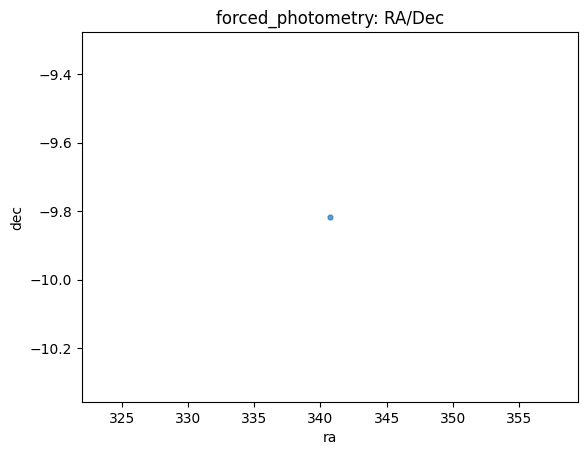

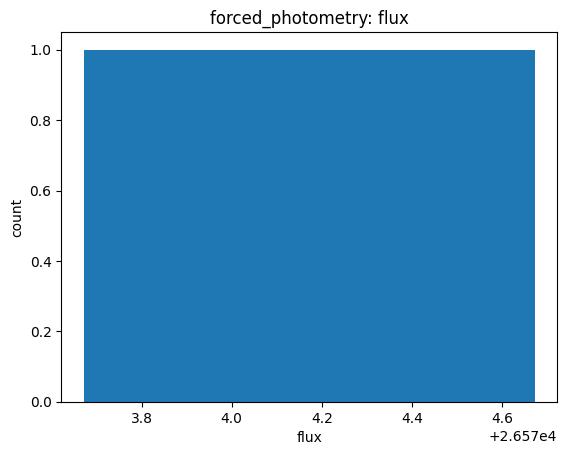

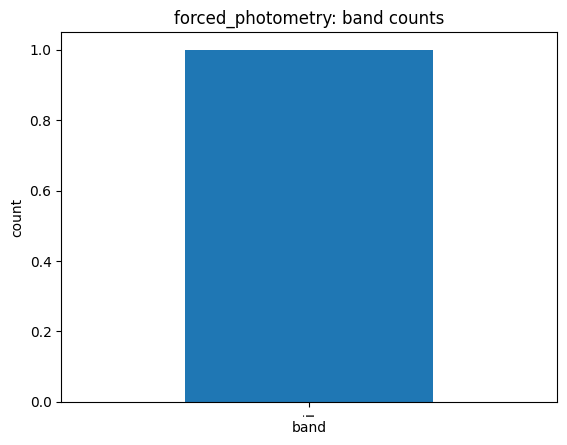

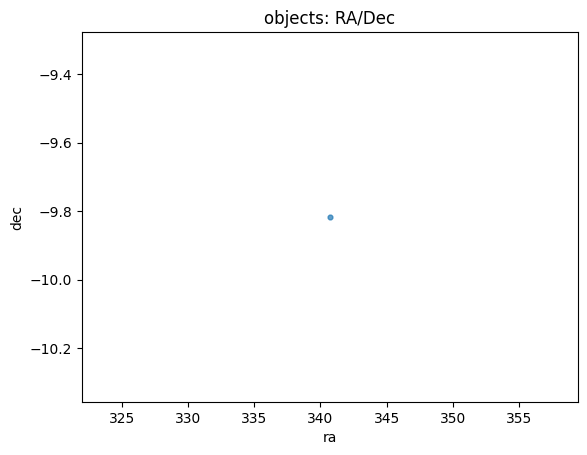

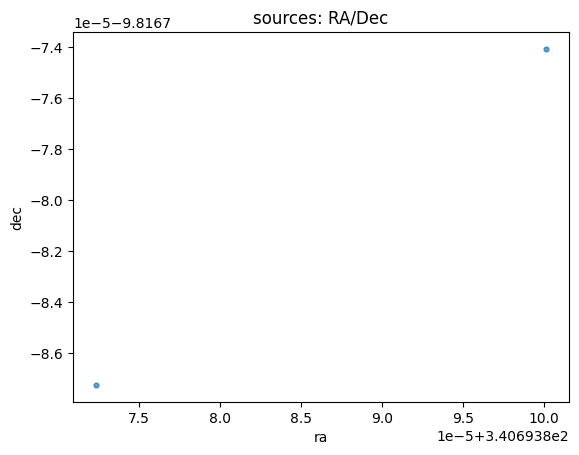

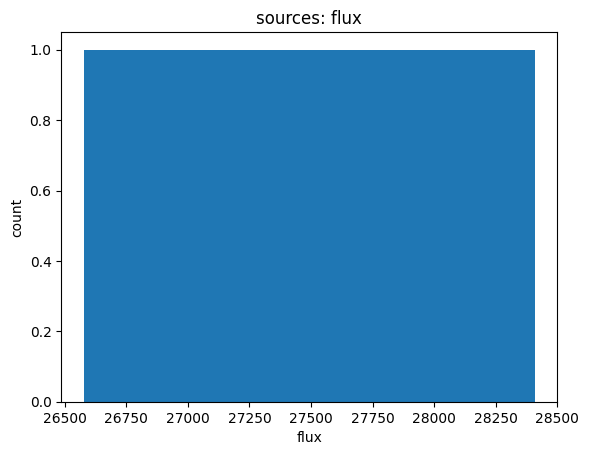

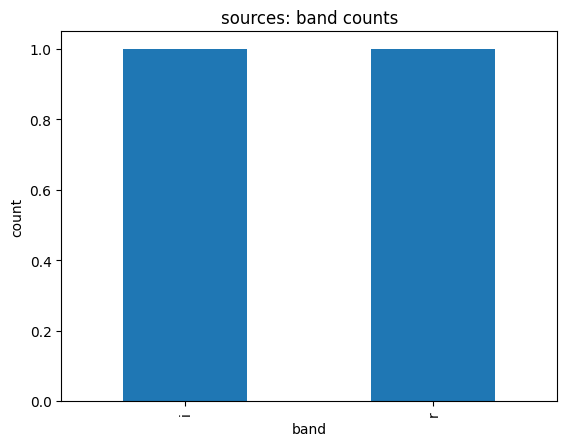

In [6]:
import matplotlib.pyplot as plt

for name, df in tables.items():
    if {"ra", "dec"}.issubset(df.columns) and len(df):
        plt.figure()
        sky_scatter(df, "ra", "dec")
        plt.title(f"{name}: RA/Dec")
    if "flux" in df.columns and df["flux"].notna().any():
        plt.figure()
        numeric_histogram(df, "flux", bins=min(10, max(1, len(df))))
        plt.title(f"{name}: flux")
    if "band" in df.columns and df["band"].notna().any():
        plt.figure()
        categorical_bar_counts(df, "band", limit=10)
        plt.title(f"{name}: band counts")
    if "tag" in df.columns and df["tag"].notna().any():
        display(group_counts(df, "tag", limit=20))

## Validation Summary

In [7]:
if paths["validation_summary"].exists():
    print(paths["validation_summary"].read_text())
else:
    print("No validation summary yet. Run scripts/validate_minimal_samples.py")

# Minimal Ingestion Validation Summary

- Created UTC: `2026-06-23T19:15:56.124440+00:00`

## sources

- `info` `non_empty`: passed - DataFrame contains rows
- `error` `required_columns`: passed - All required columns are present
- `info` `id_presence`: passed - At least one ID column has values
- `info` `provenance_columns`: passed - Normalization provenance columns are present
- `error` `ra_range`: passed - ra values are within [0, 360]
- `error` `ra_range`: passed - r:ra values are within [0, 360]
- `error` `dec_range`: passed - dec values are within [-90, 90]
- `error` `dec_range`: passed - r:dec values are within [-90, 90]
- `error` `time_sanity`: passed - time_mjd values are within a broad expected range
- `error` `time_sanity`: passed - r:midpointMjdTai values are within a broad expected range
- `info` `numeric_sanity`: passed - flux numeric range recorded
- `info` `numeric_sanity`: passed - flux_err uncertainty values are non-negative
- `error` `duplicate_keys`: passed - No dup

## Checkpoint 1 Interpretation

- What worked: real IDs were discovered from a tiny public tag lookup, and tiny `objects`, `sources`, and `fp` samples were retrieved.
- What failed: any failed endpoint attempts are recorded in `outputs/minimal_ingestion/sample_endpoint_attempts.json`.
- Still ID-gated: broader `objects`, `sources`, and `fp` work requires known IDs or a separately designed safe discovery method.
- Full-night extraction: not established by this notebook. Public REST is confirmed for sample lookup, not yet for complete nightly extraction.
- Next test: design a bounded public REST strategy for a small date/tag window and compare it with future Data Transfer requirements.